In [1]:
#!/usr/bin/env python
# -*-coding:utf-8 -*-
'''
@File    :   real_data_analysis_1.ipynb
@Time    :   2024/09/06 12:01:19
@Author  :   Menetrier Baptiste 
@Version :   1.0
@Contact :   baptiste.menetrier@ecole-navale.fr
@Desc    :   None
'''

# ======================================================================================================================
# Import
# ======================================================================================================================
# %matplotlib ipympl

import sys 
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

import os 
import pandas as pd
import numpy as np

import scipy.fft as sf
import scipy.signal as sp
import matplotlib.pyplot as plt

from get_data.ais.ais_tools import *
from real_data_analysis.signal_processing_utils import *
from real_data_analysis.real_data_utils import *
from publication.publication_figure import PubFigure
from localisation.verlinden.misc.verlinden_utils import load_rhumrum_obs_pos

PubFigure(label_fontsize=22, title_fontsize=24, legend_fontsize=16, ticks_fontsize=20)

In [2]:
# Def frequency properties
nperseg = 2**13
noverlap = int(nperseg * 3 / 4)

fmin = 4
fmax = 46
filter_type = "bandpass"
filter_corners = 4

freq_properties = {"fmin": fmin, "fmax": fmax, "filter_type": filter_type, "filter_corners": filter_corners, "noverlap": noverlap, "nperseg": nperseg}

# Analyse pour Samuel 01/10/2025

In [3]:
ch = ["BDH"]
# date = "2013-05-08 08:00:00"
date = "2013-05-09 13:30:00"
duration_s = 80 * 60 

rcv_id = "RR47"
# interesting_dates = [
#     # "2013-05-05 16:00:00",
#     # "2013-05-07 09:00:00",
#     "2013-05-08 08:00:00",
#     # "2013-05-09 13:30:00",
#     # "2013-05-11 16:00:00",
#     # "2013-05-14 06:00:00",
#     # "2013-05-15 21:00:00",
#     # "2013-05-22 12:00:00",
#     # "2013-05-25 19:00:00",
# ]

root_img = r"C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\img\\illustration\\real_data"
root_img = os.path.join(root_img, "ship_signature_samuel")

if not os.path.exists(root_img):
    os.makedirs(root_img)

In [4]:
fmin = 2
fmax = 48
nperseg = 2**12
freq_properties = {
    "fmin": fmin,
    "fmax": fmax,
    "filter_type": filter_type,
    "filter_corners": filter_corners,
    "noverlap": int(nperseg * 3/4),
    "nperseg": nperseg,
}
# Define dsp parameters

save = True
root_wav = root_img

In [5]:
# Load data
data = load_wav_data(
    date=date,
    rcv_id=rcv_id,
    duration_s=duration_s,
    ch=ch,
    freq_properties=freq_properties,
    root_wav=root_wav
)
data["root_img"] = root_img

dsp_args = {
    "nperseg": nperseg,
    "overlap_coef": 3 / 4,
    "window": "hann",
    "fs": data["sig"].meta.sampling_rate,
    "fmin": fmin,
    "fmax": fmax,
}

# Derive dsp
get_dsp(data, dsp_args=dsp_args)

# Plot stft
plot_stft(data, save=save)

# Plot dsp
fmin_plot = fmin
fmax_plot = fmax
plot_dsp(data, fmin=fmin_plot, fmax=fmax_plot, save=save)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


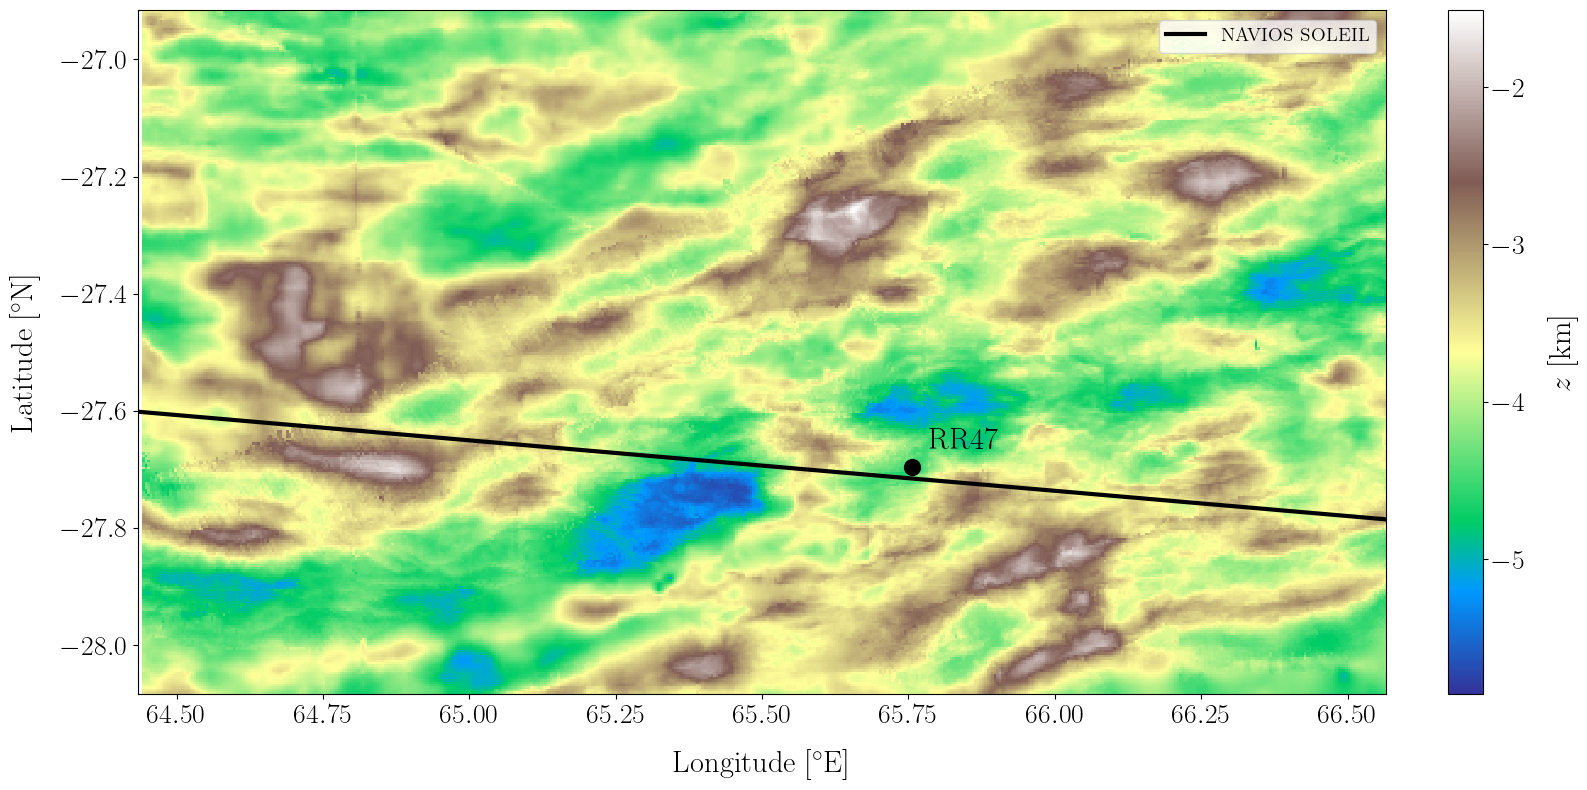

In [6]:
# Plot trajectory of a given ship over the SWIR bathymétrie
lon_min = 65
lon_max = 66
lat_min = -28
lat_max = -27
mmsi, ais_data = find_mmsi_from_date(date, duration_s)

# Save ais data 
fpath = os.path.join(root_img, "ais.csv")
ais_data.to_csv(fpath)
station_id = ["RR47"]

rcv_info = {"id": station_id, "lons": [], "lats": []}
for obs_id in rcv_info["id"]:
    pos_obs = load_rhumrum_obs_pos(obs_id)
    rcv_info["lons"].append(pos_obs.lon)
    rcv_info["lats"].append(pos_obs.lat)

plot_traj_over_bathy(ais_data, rcv_info, lon_min, lon_max, lat_min, lat_max)
# plt.xlim(lon_min, lon_max)
# plt.ylim(lat_min, lat_max)

# Save 
fpath = os.path.join(root_img, "ship_traj_over_bathy.png")
plt.savefig(fpath)

In [7]:
distance = compute_distance_ship_rcv(ais_data, rcv_info)
print(distance)

{373759000: {'RR47': array([110039.52461963, 109211.2133368 , 108382.9054117 , 106055.36627838,
       104556.13779326, 103056.91573535, 101557.70038928, 100058.49205675,
        98559.29105781,  97060.09773229,  95560.91244133,  94061.73556912,
        92562.56752471,  91063.40874409,  89564.25969245,  88065.12086663,
        86565.99279792,  85066.87605502,  83567.77124745,  82068.67902927,
        80569.60010319,  79070.53522521,  77571.48520978,  76072.45093553,
        73117.24577185,  71661.08147367,  70204.94190585,  68748.82863981,
        67292.74338292,  65836.68799361,  64380.66449835,  62924.67511115,
        61468.72225572,  60012.80859094,  58556.93704   ,  57101.11082417,
        55645.3335017 ,  54189.60901307,  52733.94173374,  51278.33653579,
        49822.79886048,  48367.33480376,  46911.95121779,  45456.65583184,
        44001.45739724,  42546.36586199,  41091.39258234,  38369.54740143,
        37102.6683635 ,  35835.92663327,  34569.33730506,  33302.91776752,
    

In [8]:
# Derive CPA for each each ship and each receiver
cpa = get_cpa(ais_data=ais_data, distance=distance, rcv_info=rcv_info)
print(cpa)
# cpa = 

{373759000: {'RR47': {'lon': 65.7468091437006, 'lat': -27.714875100805028, 'time': Timestamp('2013-05-09 14:35:08'), 'r_cpa': 2273.6445563440816}}}


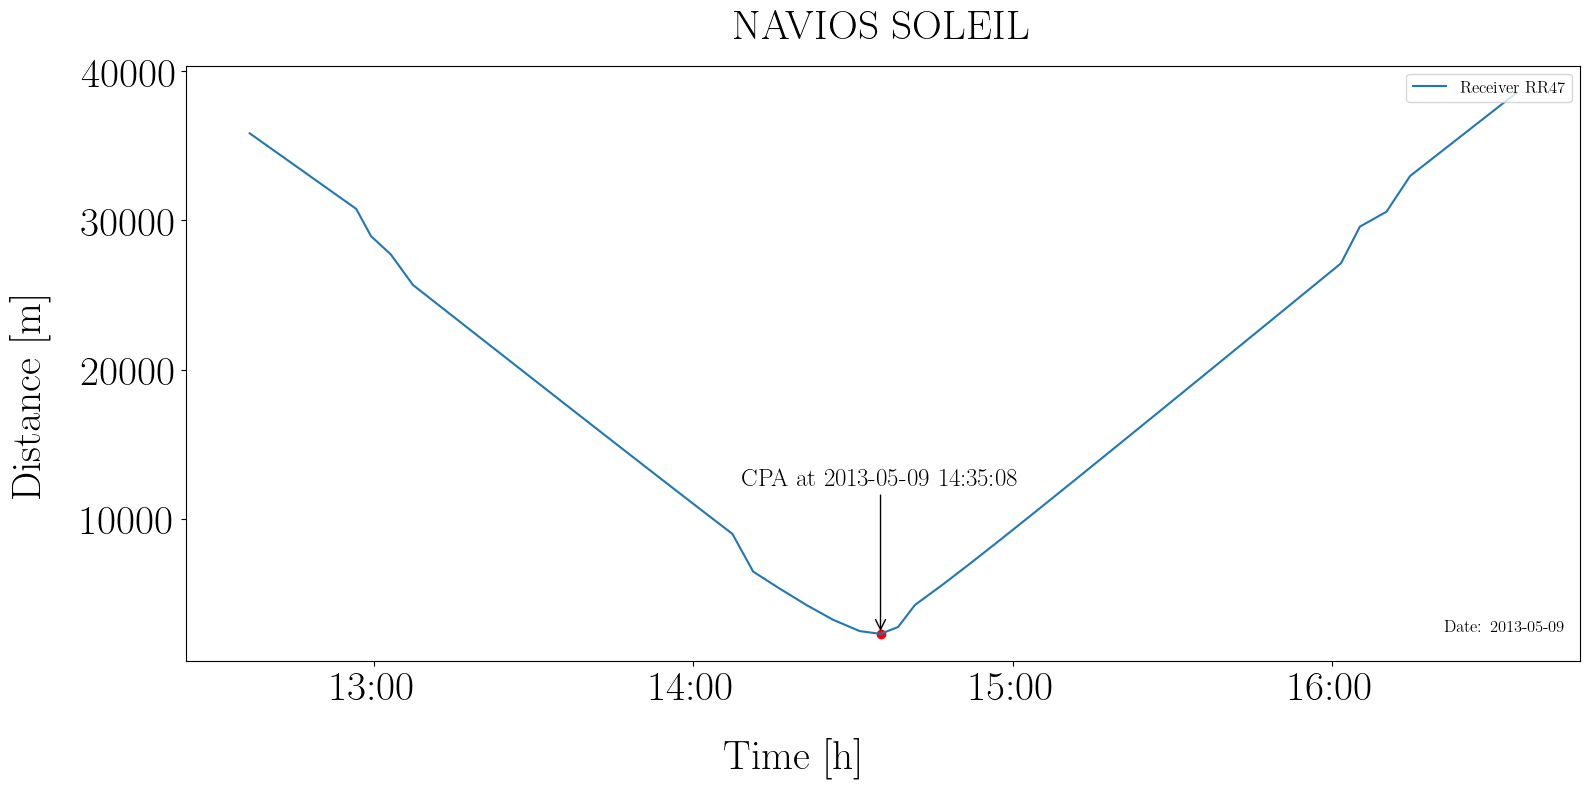

In [9]:
tmin = cpa[373759000]["RR47"]["time"] - pd.Timedelta(minutes=120)
tmax = cpa[373759000]["RR47"]["time"] + pd.Timedelta(minutes=120)
ais_data_around_cpa = ais_data.loc[np.logical_and(ais_data["time"] >= tmin, ais_data["time"] <= tmax)]
distance_around_cpa = compute_distance_ship_rcv(ais_data_around_cpa, rcv_info)

plot_distance_ship_rcv(
    ais_data=ais_data_around_cpa,
    distance=distance_around_cpa,
    cpa=cpa,
    rcv_info=rcv_info,
)


fpath = os.path.join(root_img, "dist_rcv_ship.png")
plt.savefig(fpath)

In [10]:
data

{'date': '2013-05-09 13:30:00',
 'duration_s': 4800,
 'rcv_id': 'RR47',
 'ch': ['BDH'],
 'data': array([ 1.08270589, -1.00898996,  1.19213173, ..., -0.07311159,
        -0.07223799, -0.07481011]),
 'sig': YV.RR47.00.BDH | 2013-05-09T13:30:00.000000Z - 2013-05-09T14:50:00.000000Z | 100.0 Hz, 480001 samples,
 'f': array([0.00000000e+00, 2.44140625e-02, 4.88281250e-02, ...,
        4.99511719e+01, 4.99755859e+01, 5.00000000e+01]),
 'tt': array([   0.  ,   10.24,   20.48,   30.72,   40.96,   51.2 ,   61.44,
          71.68,   81.92,   92.16,  102.4 ,  112.64,  122.88,  133.12,
         143.36,  153.6 ,  163.84,  174.08,  184.32,  194.56,  204.8 ,
         215.04,  225.28,  235.52,  245.76,  256.  ,  266.24,  276.48,
         286.72,  296.96,  307.2 ,  317.44,  327.68,  337.92,  348.16,
         358.4 ,  368.64,  378.88,  389.12,  399.36,  409.6 ,  419.84,
         430.08,  440.32,  450.56,  460.8 ,  471.04,  481.28,  491.52,
         501.76,  512.  ,  522.24,  532.48,  542.72,  552.96,  56

In [11]:
f_peaks = data["f_peaks"]

f0 = f_peaks[0] / 2
if0 = 1
print("Harmonique de rang pair :")
while 2*if0 < len(f_peaks):
    ri0_even = f_peaks[2*if0] / f0
    ri0_even = np.round(ri0_even, 2)
    print(f"f{2*if0} / f0 = {ri0_even}")
    if0 += 1 

if0 = 0
print("Harmonique de rang impair :")
while 2 * if0 < len(f_peaks):
    ri0_odd = f_peaks[2 * if0+1] / f0
    ri0_odd = np.round(ri0_odd, 2)
    print(f"f{2*if0+1} / f0 = {ri0_odd}")
    if0 += 1

r21 = f_peaks[1] / f_peaks[0]
r31 = f_peaks[2] / f_peaks[0]

Harmonique de rang pair :
f2 / f0 = 4.01
f4 / f0 = 6.01
f6 / f0 = 8.0
f8 / f0 = 10.03
f10 / f0 = 12.0
f12 / f0 = 13.94
f14 / f0 = 15.94
f16 / f0 = 18.1
f18 / f0 = 20.1
f20 / f0 = 22.07
f22 / f0 = 23.96
f24 / f0 = 25.87
f26 / f0 = 27.94
Harmonique de rang impair :
f1 / f0 = 3.01
f3 / f0 = 5.01
f5 / f0 = 7.01
f7 / f0 = 9.07
f9 / f0 = 11.1
f11 / f0 = 12.93
f13 / f0 = 14.93
f15 / f0 = 17.11
f17 / f0 = 19.11
f19 / f0 = 21.16
f21 / f0 = 22.98
f23 / f0 = 24.93
f25 / f0 = 27.01
f27 / f0 = 28.86


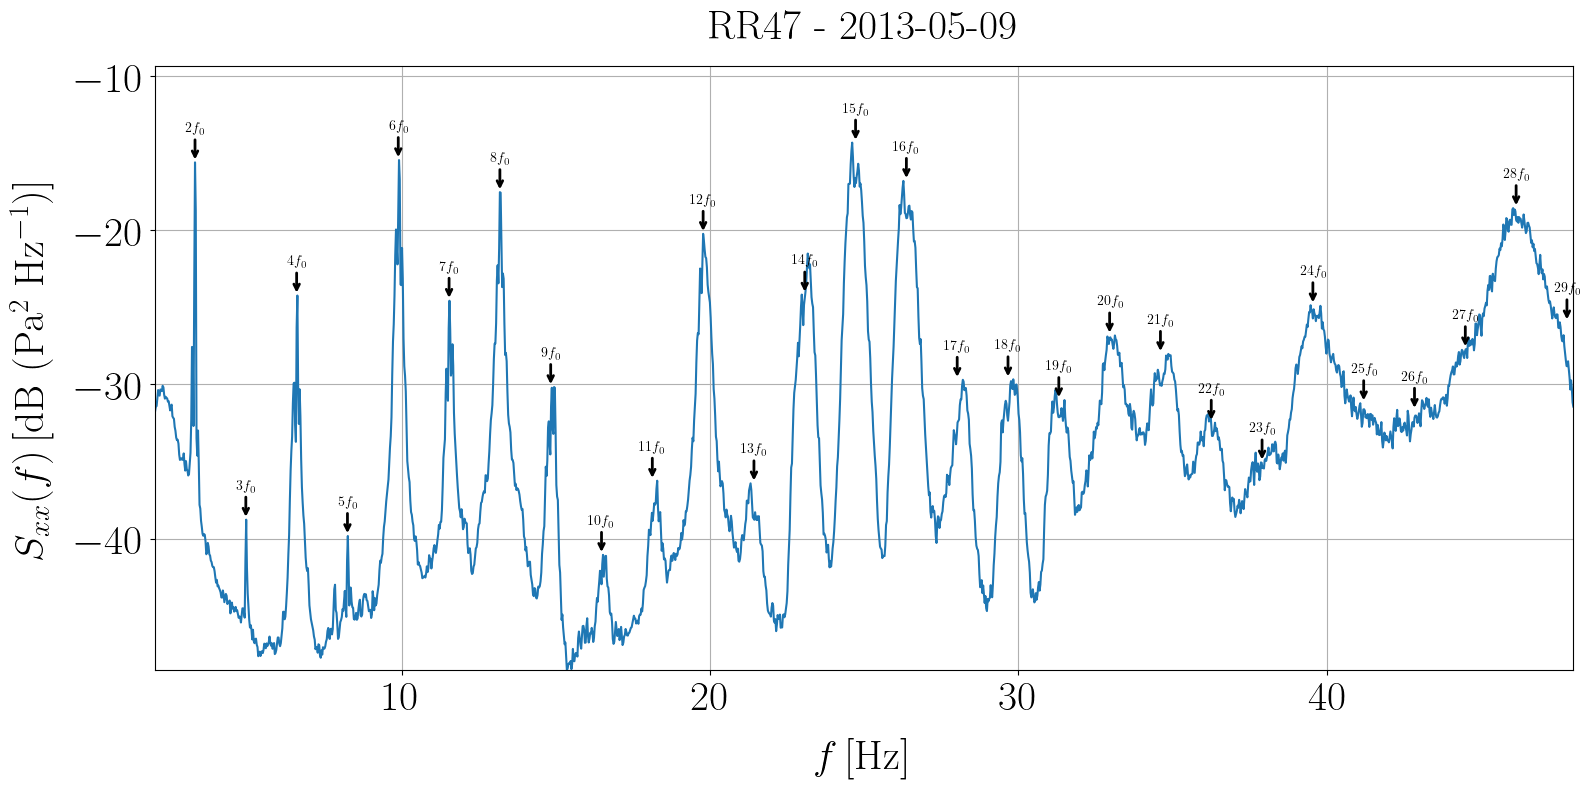

In [13]:
idx_visible_peaks = np.arange(0, )
harmonic_labels = [fr"{k+2}$f_0$" for k in range(len(f_peaks))]
Pxx_in_band = data["Pxx_in_band"]
idx_f_peaks = data["idx_f_peaks"]

plt.figure()
plt.plot(data["ff_in_band"], 10 * np.log10(data["Pxx_in_band"]))

# Add labels with an arrow pointing at the top of each peak
k_h = 2
for i, txt in enumerate(harmonic_labels):
    plt.annotate(
        txt,
        (k_h * f0, 10 * np.log10(Pxx_in_band[idx_f_peaks[i]])),
        xytext=(k_h * f0, 10 * np.log10(Pxx_in_band[idx_f_peaks[i]]) + 2),
        ha="center",
        arrowprops=dict(arrowstyle="->", lw=2),
    )
    k_h += 1

plt.xlabel(r"$f \, \textrm{[Hz]}$")
plt.ylabel(r"$S_{xx}(f) \, \textrm{[dB (Pa$^2$ Hz$^{-1}$)]}$")
plt.grid()
plt.xlim(fmin, fmax)
pxx_min = 10 * np.log10(np.min(Pxx_in_band))
pxx_max = 10 * np.log10(np.max(Pxx_in_band))
plt.ylim(pxx_min, pxx_max + 5)

date_str = data["tt_datetime"][0].strftime("%Y-%m-%d")
title = f"{data['rcv_id']} - {date_str}"
plt.title(title)

# Save
fpath = os.path.join(root_img, "dsp_with_harmonics.png")
plt.savefig(fpath)